In [9]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import torch
import torchvision.transforms as T
from sklearn.manifold import TSNE
import seaborn as sns
from torchvision.models import resnet18, ResNet18_Weights

In [ ]:
root = ""#waterbird datset 

meta = pd.read_csv(os.path.join(root, "metadata.csv"))  

In [11]:
meta['y'].value_counts()

y
0    9125
1    2663
Name: count, dtype: int64

In [12]:
bird_map = {0: "landbird", 1: "waterbird"}
bg_map = {0: "land background", 1: "water background"}

meta["bird_type"] = meta["y"].map(bird_map)
meta["background"] = meta["place"].map(bg_map)

In [13]:
meta

,img_id,img_filename,y,split,place,place_filename,bird_type,background
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,2,1,/o/ocean/00002178.jpg,waterbird,water background
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/l/lake/natural/00000065.jpg,waterbird,water background
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,2,0,/b/bamboo_forest/00000131.jpg,waterbird,land background
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/o/ocean/00001268.jpg,waterbird,water background
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,1,/o/ocean/00003147.jpg,waterbird,water background
...,...,...,...,...,...,...,...,...
11783,11784,200.Common_Yellowthroat/Common_Yellowthroat_00...,0,0,0,/f/forest/broadleaf/00001288.jpg,landbird,land background
11784,11785,200.Common_Yellowthroat/Common_Yellowthroat_00...,0,2,0,/f/forest/broadleaf/00004142.jpg,landbird,land background
11785,11786,200.Common_Yellowthroat/Common_Yellowthroat_00...,0,2,0,/f/forest/broadleaf/00003041.jpg,landbird,land background
11786,11787,200.Common_Yellowthroat/Common_Yellowthroat_00...,0,0,0,/b/bamboo_forest/00004628.jpg,landbird,land background


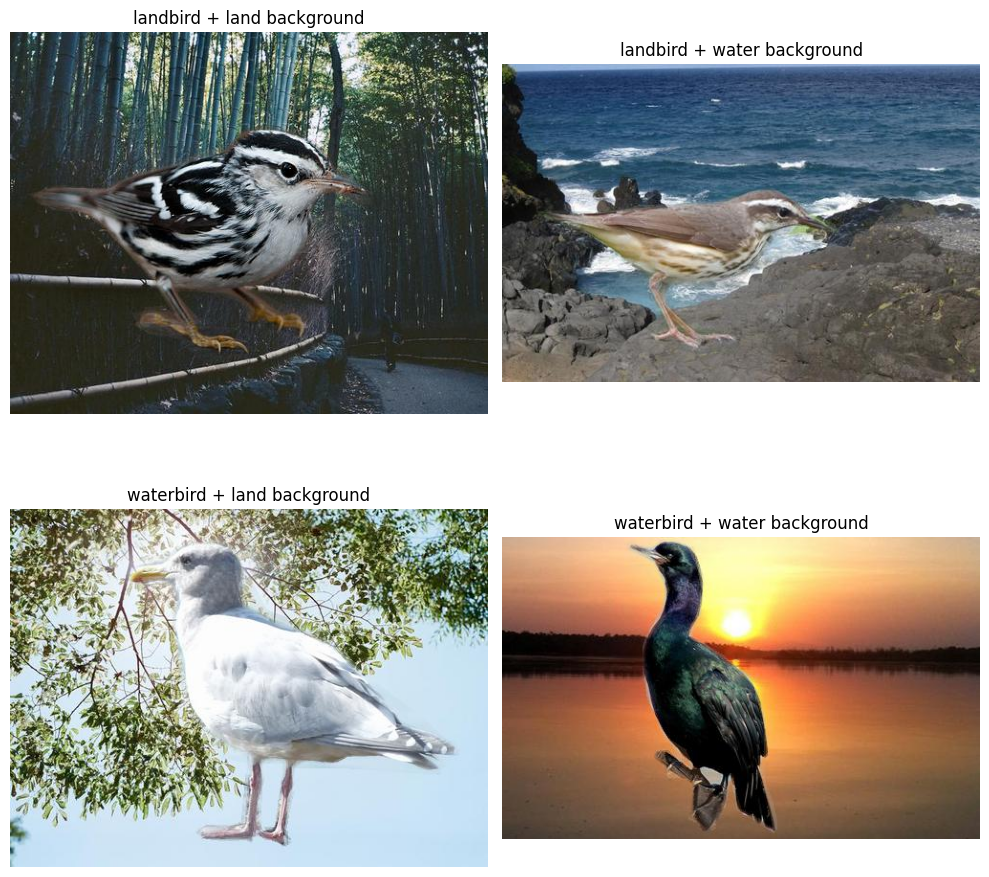

In [14]:
groups = meta.groupby(['bird_type', 'background'])

fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes = axes.flatten()
for ax, ((bird, bg), group_df) in zip(axes, groups):
    sample = group_df.sample(1).iloc[0]
    img_path = os.path.join(root, sample['img_filename'])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{bird} + {bg}")
    ax.axis('off')
plt.tight_layout()
plt.show()

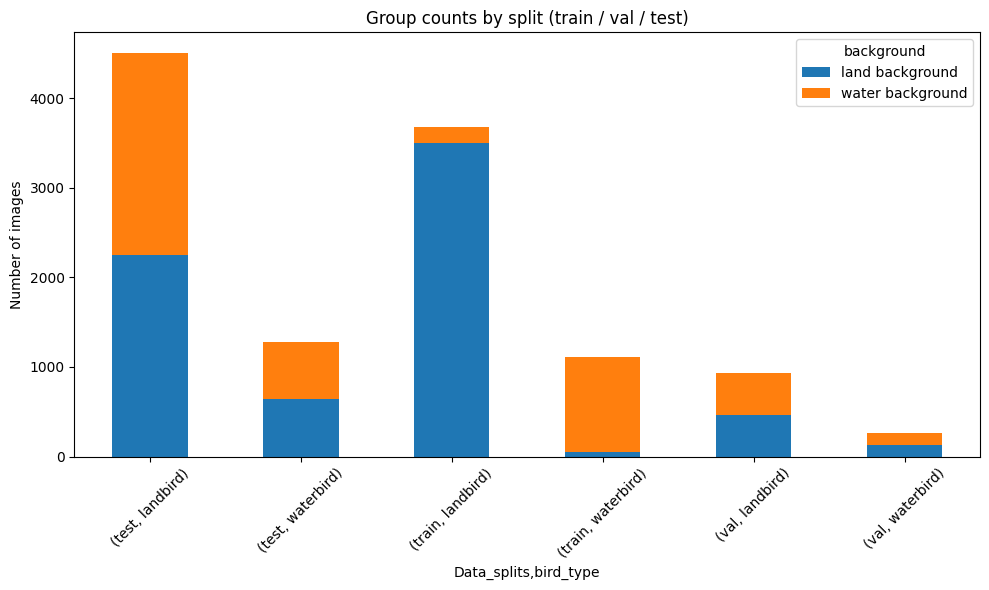

In [15]:
split_map = {0: 'train', 1: 'val', 2: 'test'}
meta['Data_splits'] = meta['split'].map(split_map)

group_counts = (
    meta
    .groupby(['Data_splits', 'bird_type', 'background'])['img_filename']
    .count()
    .reset_index()
)

pivot = group_counts.pivot_table(
    index=['Data_splits', 'bird_type'],
    columns='background',
    values='img_filename',
    fill_value=0
)

# Plot
pivot.plot(kind='bar', stacked=True, figsize=(10,6))
plt.ylabel("Number of images")
plt.title("Group counts by split (train / val / test)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Using: cuda


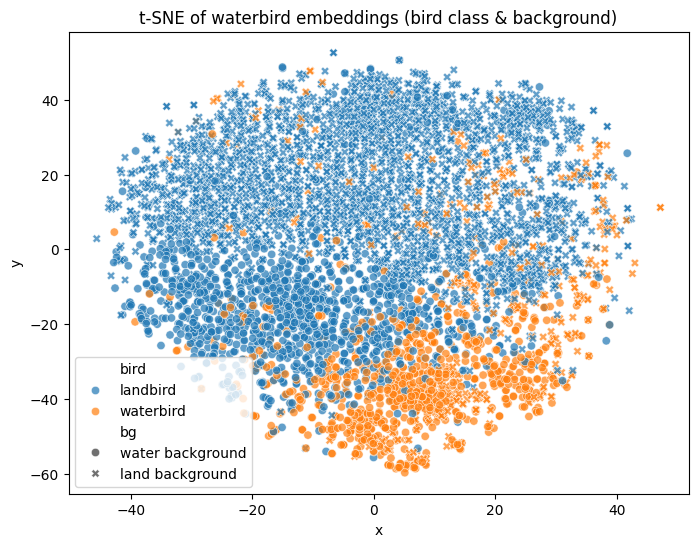

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

weights = ResNet18_Weights.IMAGENET1K_V1  # or ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

model = torch.nn.Sequential(*(list(model.children())[:-1]))  # remove classifier
model = model.to(device)
model.eval()

transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225])
])

embeddings = []
labels = []

# Sample 5000 rows from metadata
subset = meta.sample(5000)

for idx, row in subset.iterrows():

    img_path = os.path.join(root, row['img_filename'])
    img = Image.open(img_path).convert("RGB")

    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = model(x)
        feat = feat.squeeze().cpu().numpy()   # move result back to CPU

    embeddings.append(feat)
    labels.append((row['bird_type'], row['background']))

# Convert to DataFrame
embeddings = pd.DataFrame(embeddings)

tsne = TSNE(n_components=2, random_state=42)
emb2d = tsne.fit_transform(embeddings)

df_tsne = pd.DataFrame({
    'x': emb2d[:,0],
    'y': emb2d[:,1],
    'bird': [l[0] for l in labels],
    'bg': [l[1] for l in labels]
})

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_tsne, x='x', y='y', hue='bird', style='bg', alpha=0.7)
plt.title("t-SNE of waterbird embeddings (bird class & background)")
plt.show()
